In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.api as smt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(
    "exchange_rate.csv",
    parse_dates=["date"],
    dayfirst=True,
    index_col="date"
)
print(df.info())
print(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None
(7588, 1)


,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


# 1. Data Processing and Exploration

In [3]:
# Handle missing values using forward fill (ffill)
df.ffill(inplace=True)
print("Missing values after ffill:")
print(df.isnull().sum())
df.head()

Missing values after ffill:
Ex_rate    0
dtype: int64


,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [4]:
print(df.duplicated().sum())

2258


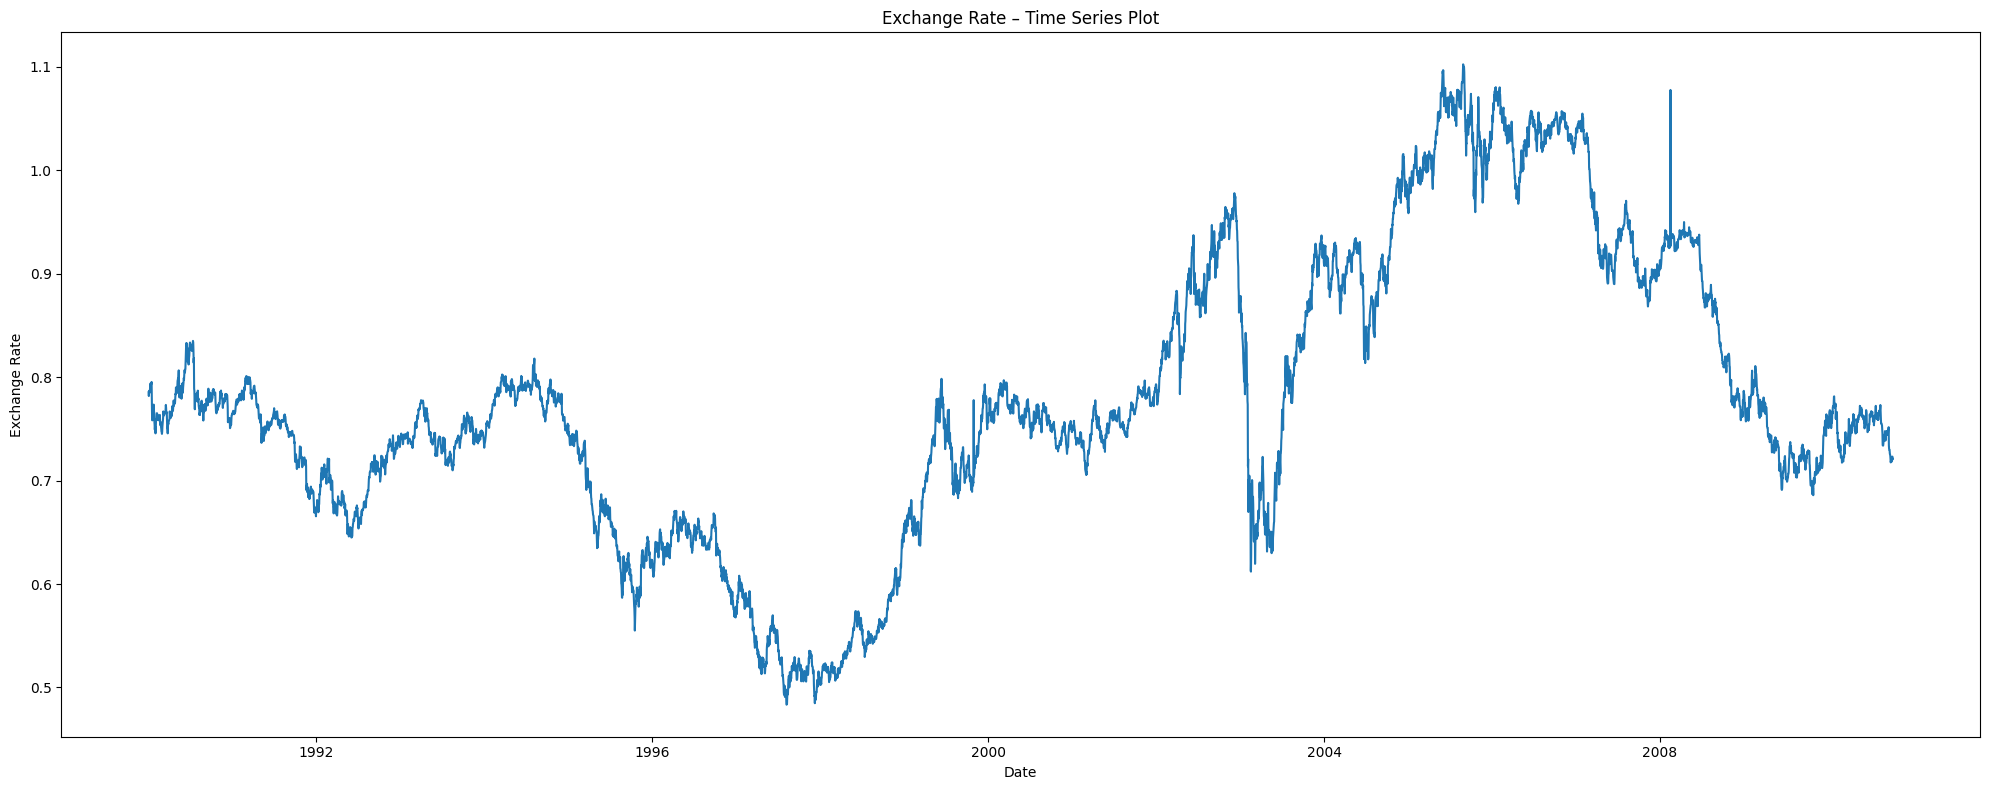

In [5]:
plt.figure(figsize=(20, 8))
plt.plot(df)
plt.title("Exchange Rate – Time Series Plot")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.tight_layout()
plt.show()

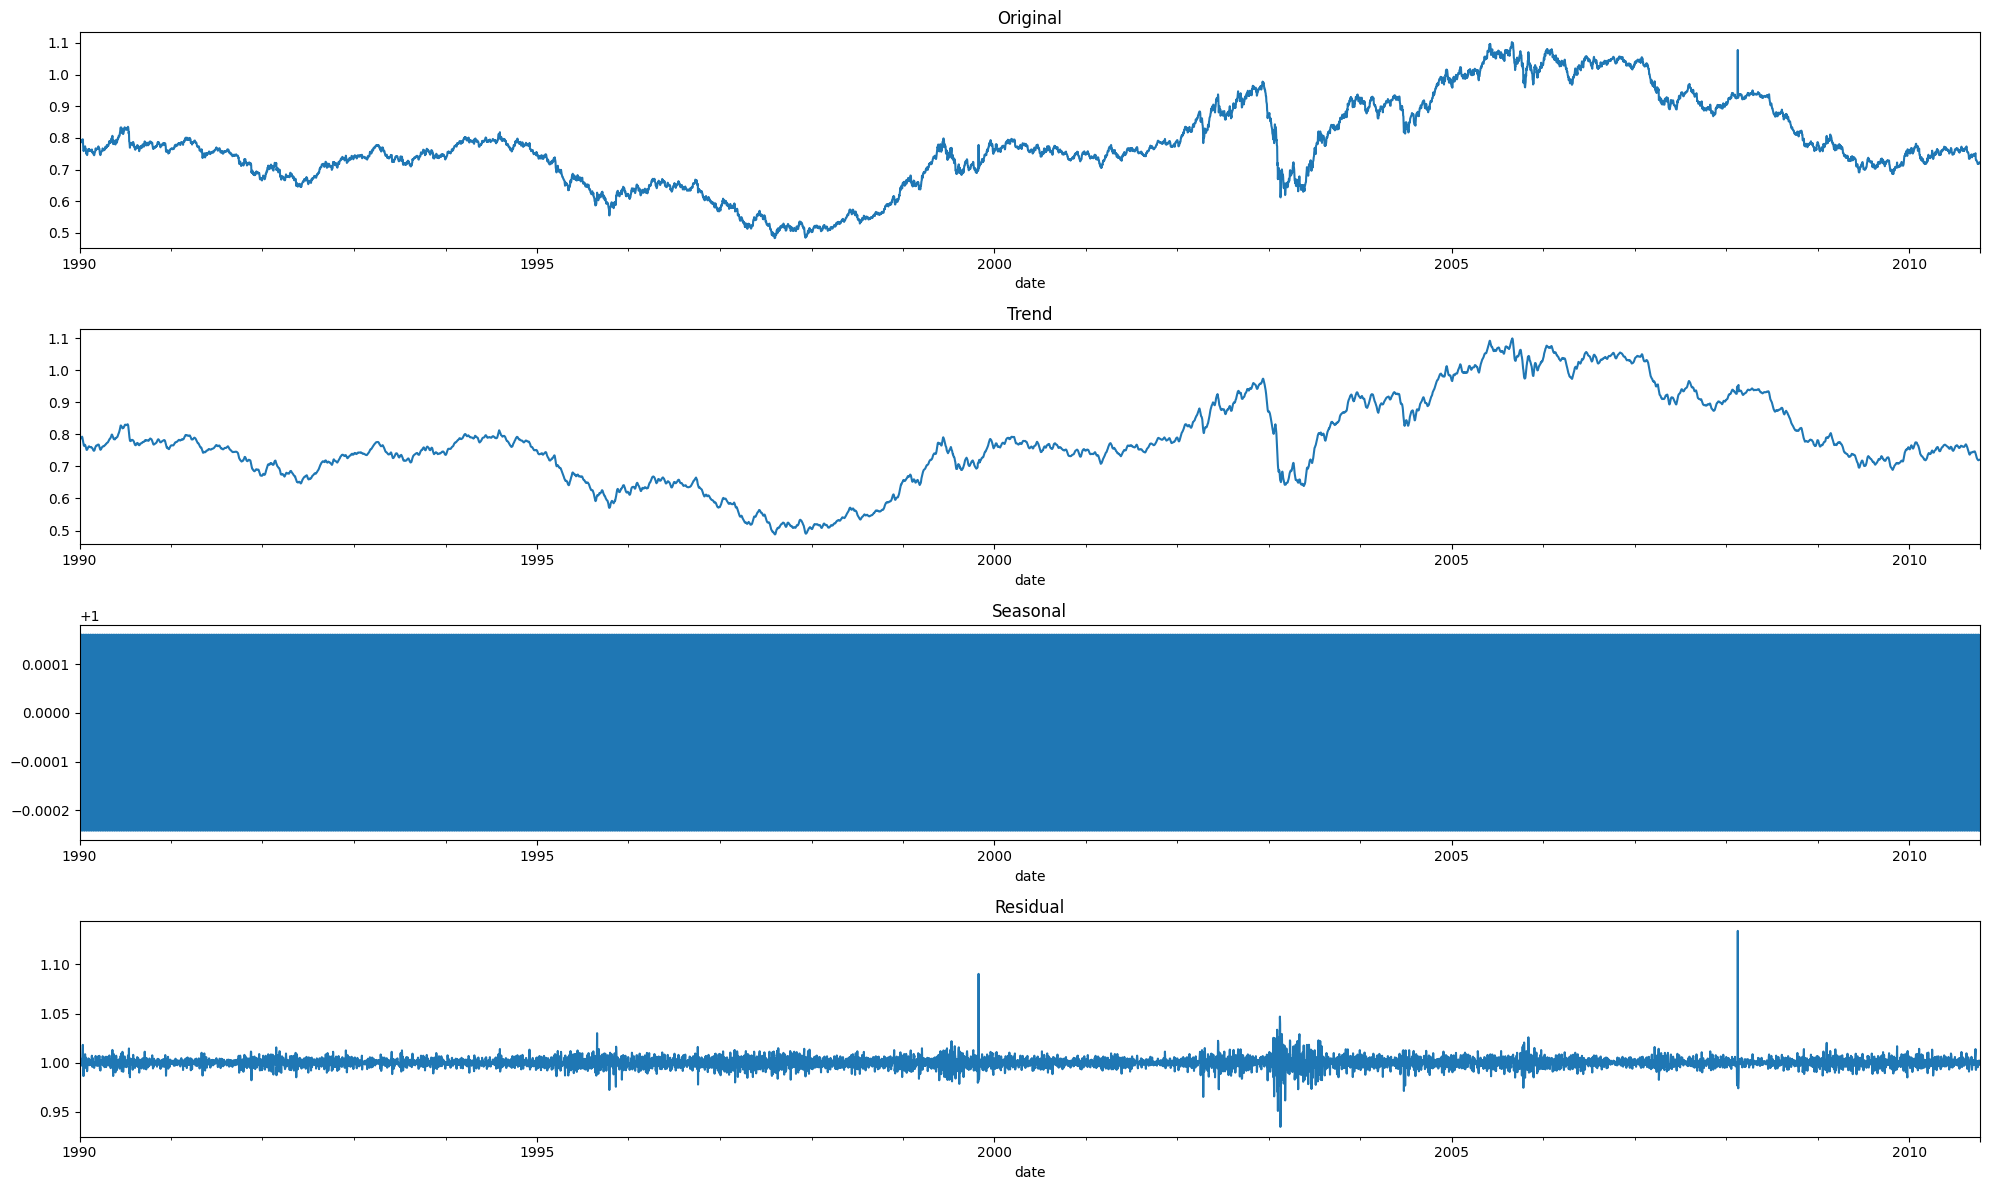

In [6]:
result = seasonal_decompose(df['Ex_rate'], model="multiplicative")

fig, axes = plt.subplots(4, 1, figsize=(20, 12))
df['Ex_rate'].plot(ax=axes[0], title='Original')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

The decomposition shows the data is not strongly seasonal.

# 2. Model Building

In [7]:
def test_stationarity(timeseries_col):
    rolmean = timeseries_col.rolling(window=12).mean()
    rolstd  = timeseries_col.rolling(window=12).std()

    plt.figure(figsize=(20, 8))
    plt.plot(timeseries_col, color='blue',  label='Original')
    plt.plot(rolmean,        color='red',   label='Rolling Mean')
    plt.plot(rolstd,         color='green', label='Rolling Std')
    plt.legend(loc='best')
    plt.title(f'Rolling Mean & Std – {timeseries_col.name}')
    plt.tight_layout()
    plt.show()

    print('Results of Augmented Dickey-Fuller Test:\n')
    df_test  = adfuller(timeseries_col)
    my_output = pd.Series(df_test[0:4],
                          index=['Test Statistic', 'p-value',
                                 '#Lags Used', 'Number of Observations Used'])
    for k, v in df_test[4].items():
        my_output[f'Critical Value ({k})'] = v
    print(my_output)

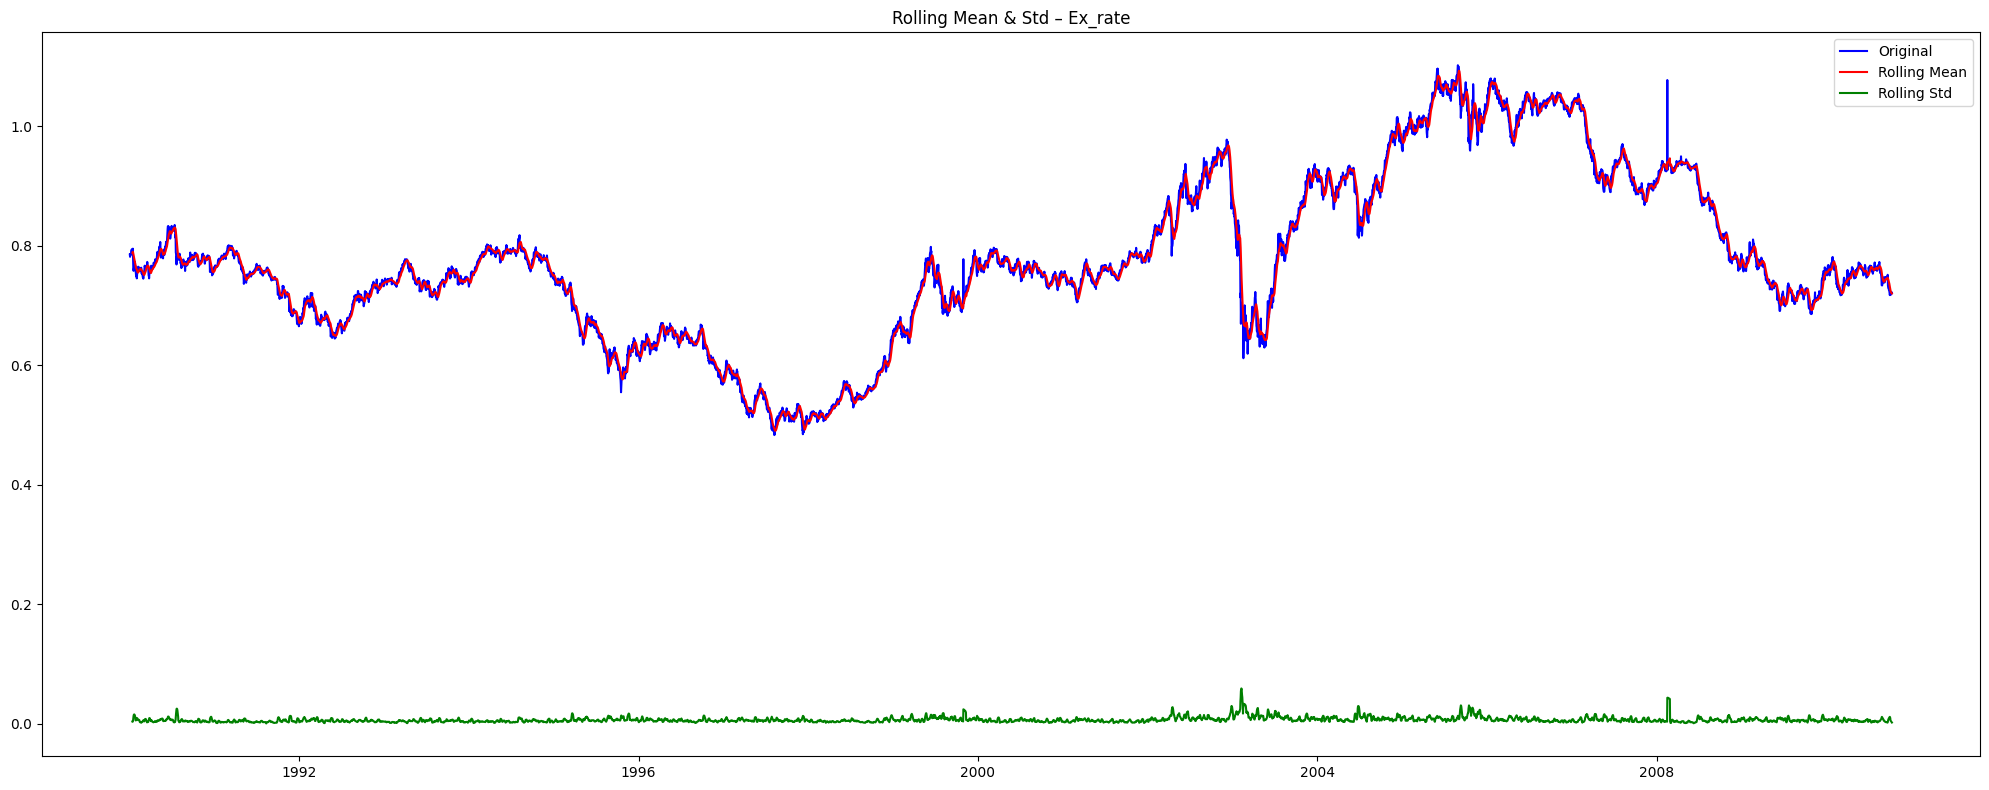

Results of Augmented Dickey-Fuller Test:

Test Statistic                   -1.664994
p-value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


'\n - Test Statistic (-1.66) is not below the 5% critical value (-2.86).\n - p-value > 0.05  =>  series is NOT stationary => differencing required.\n'

In [8]:
test_stationarity(df['Ex_rate'])
'''
 - Test Statistic (-1.66) is not below the 5% critical value (-2.86).
 - p-value > 0.05  =>  series is NOT stationary => differencing required.
'''

In [9]:
# Seasonal differencing (lag=12)
df['Ex_Rate_Diff'] = df['Ex_rate'] - df['Ex_rate'].shift(12)
df.dropna(inplace=True)

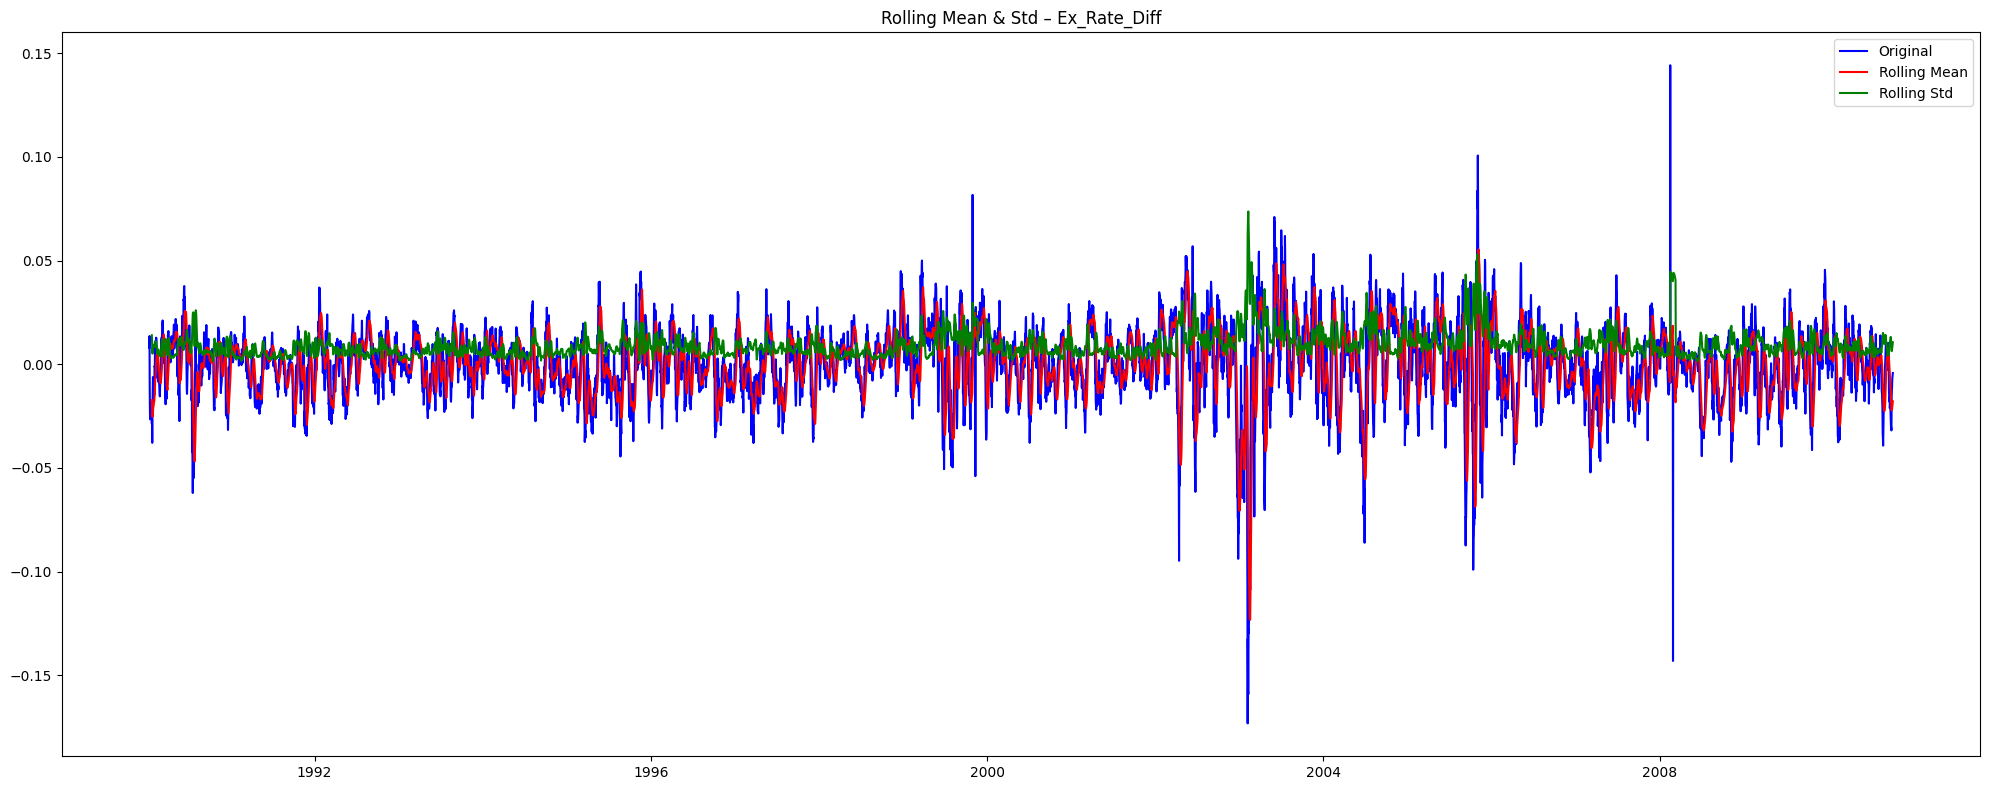

Results of Augmented Dickey-Fuller Test:

Test Statistic                -1.056518e+01
p-value                        7.549185e-19
#Lags Used                     3.600000e+01
Number of Observations Used    7.539000e+03
Critical Value (1%)           -3.431218e+00
Critical Value (5%)           -2.861923e+00
Critical Value (10%)          -2.566974e+00
dtype: float64


In [10]:
test_stationarity(df['Ex_Rate_Diff'])

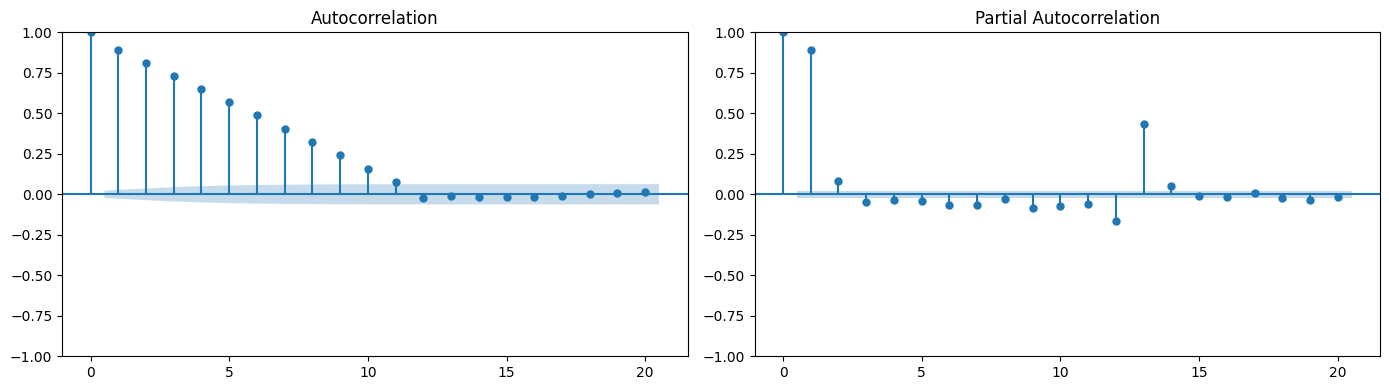

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
smt.graphics.plot_acf (df['Ex_Rate_Diff'], lags=20, ax=axes[0])
smt.graphics.plot_pacf(df['Ex_Rate_Diff'], lags=20, ax=axes[1])
plt.tight_layout()
plt.show()
# ACF  significant lags: 1-11  -> q parameter
# PACF significant lags: 1-2   -> p parameter

In [12]:
model        = ARIMA(df['Ex_rate'], order=(5, 1, 1))
result_arima = model.fit()
print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7576
Model:                 ARIMA(5, 1, 1)   Log Likelihood               28006.479
Date:                Tue, 17 Mar 2026   AIC                         -55998.958
Time:                        06:17:37   BIC                         -55950.430
Sample:                    01-13-1990   HQIC                        -55982.302
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0667      0.671     -0.099      0.921      -1.381       1.248
ar.L2          0.0057      0.088      0.065      0.948      -0.167       0.179
ar.L3         -0.0165      0.007     -2.263      0.0

## 2a. Residual Diagnostic Check

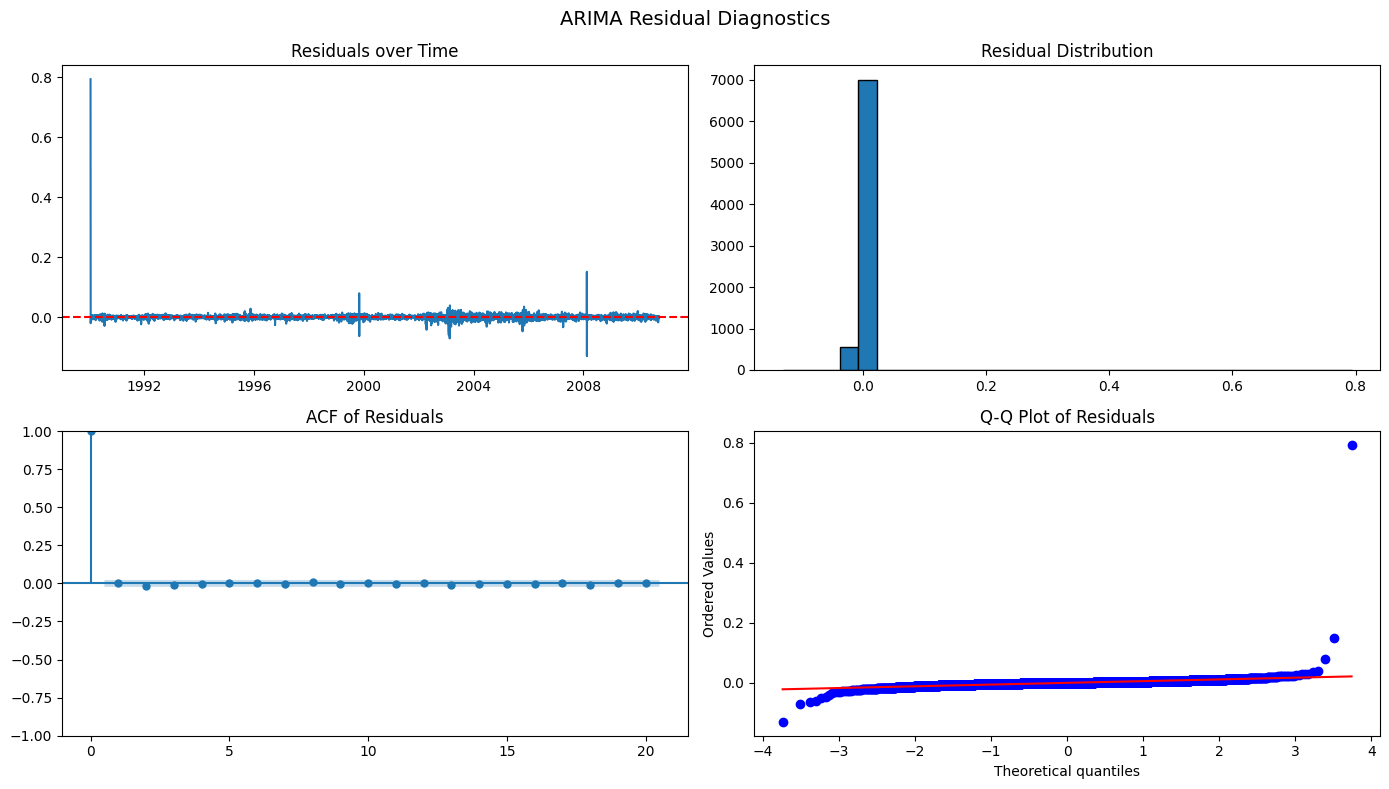


Residual Summary Statistics:
count    7576.000000
mean        0.000094
std         0.010913
min        -0.130012
25%        -0.002387
50%         0.000136
75%         0.002588
max         0.793500
dtype: float64

Mean of residuals: 0.000094  (should be close to 0)


In [13]:
# Plot residuals to check for patterns / heteroscedasticity
residuals = result_arima.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ARIMA Residual Diagnostics', fontsize=14)

# 1. Residual line plot
axes[0, 0].plot(residuals)
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].axhline(0, color='red', linestyle='--')

# 2. Residual histogram
axes[0, 1].hist(residuals, bins=30, edgecolor='black')
axes[0, 1].set_title('Residual Distribution')

# 3. ACF of residuals
smt.graphics.plot_acf(residuals.dropna(), lags=20, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals')

# 4. Q-Q plot
import scipy.stats as stats
stats.probplot(residuals.dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

print("\nResidual Summary Statistics:")
print(residuals.describe())
print(f"\nMean of residuals: {residuals.mean():.6f}  (should be close to 0)")

In [14]:
# Ljung-Box test – checks if residuals are white noise
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("Ljung-Box Test (p-value > 0.05 => residuals are white noise):")
print(lb_test)

Ljung-Box Test (p-value > 0.05 => residuals are white noise):
     lb_stat  lb_pvalue
10  4.929424   0.895842
20  7.231384   0.995854


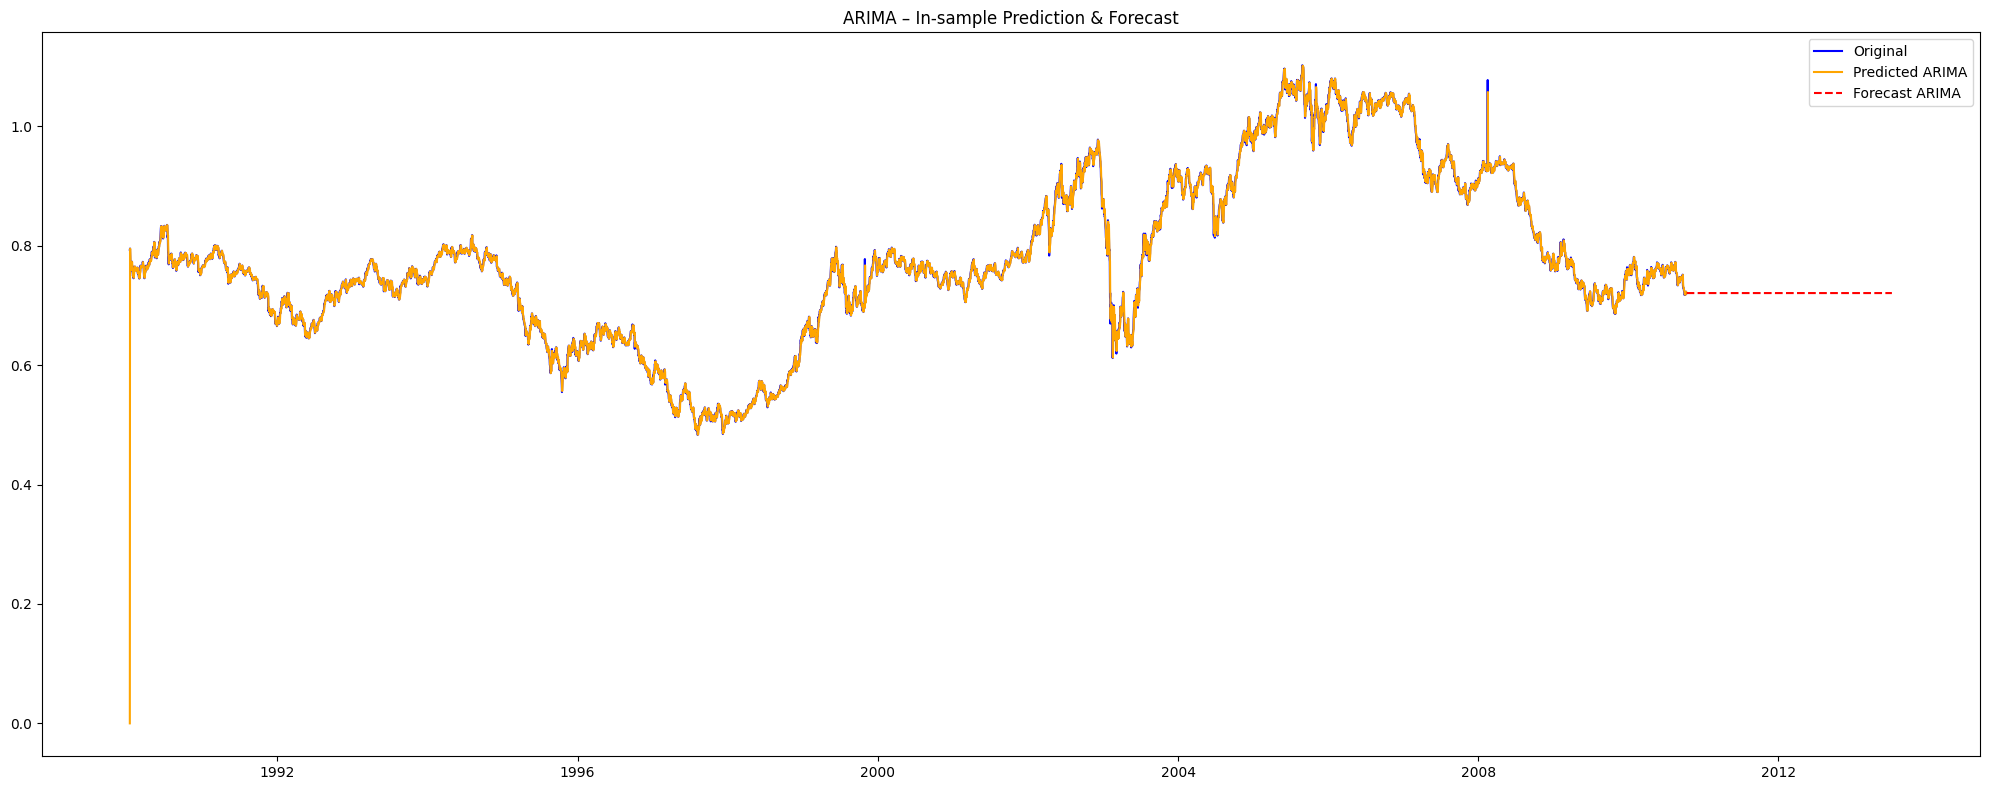

In [15]:
df['predicted_arima'] = result_arima.predict()
forecast_arima        = result_arima.forecast(1000)

plt.figure(figsize=(20, 8))
plt.plot(df['Ex_rate'],          label='Original',        color='blue')
plt.plot(df['predicted_arima'],  label='Predicted ARIMA', color='orange')
plt.plot(forecast_arima,         label='Forecast ARIMA',  color='red', linestyle='--')
plt.title('ARIMA – In-sample Prediction & Forecast')
plt.legend()
plt.tight_layout()
plt.show()

# 3. SARIMAX Model

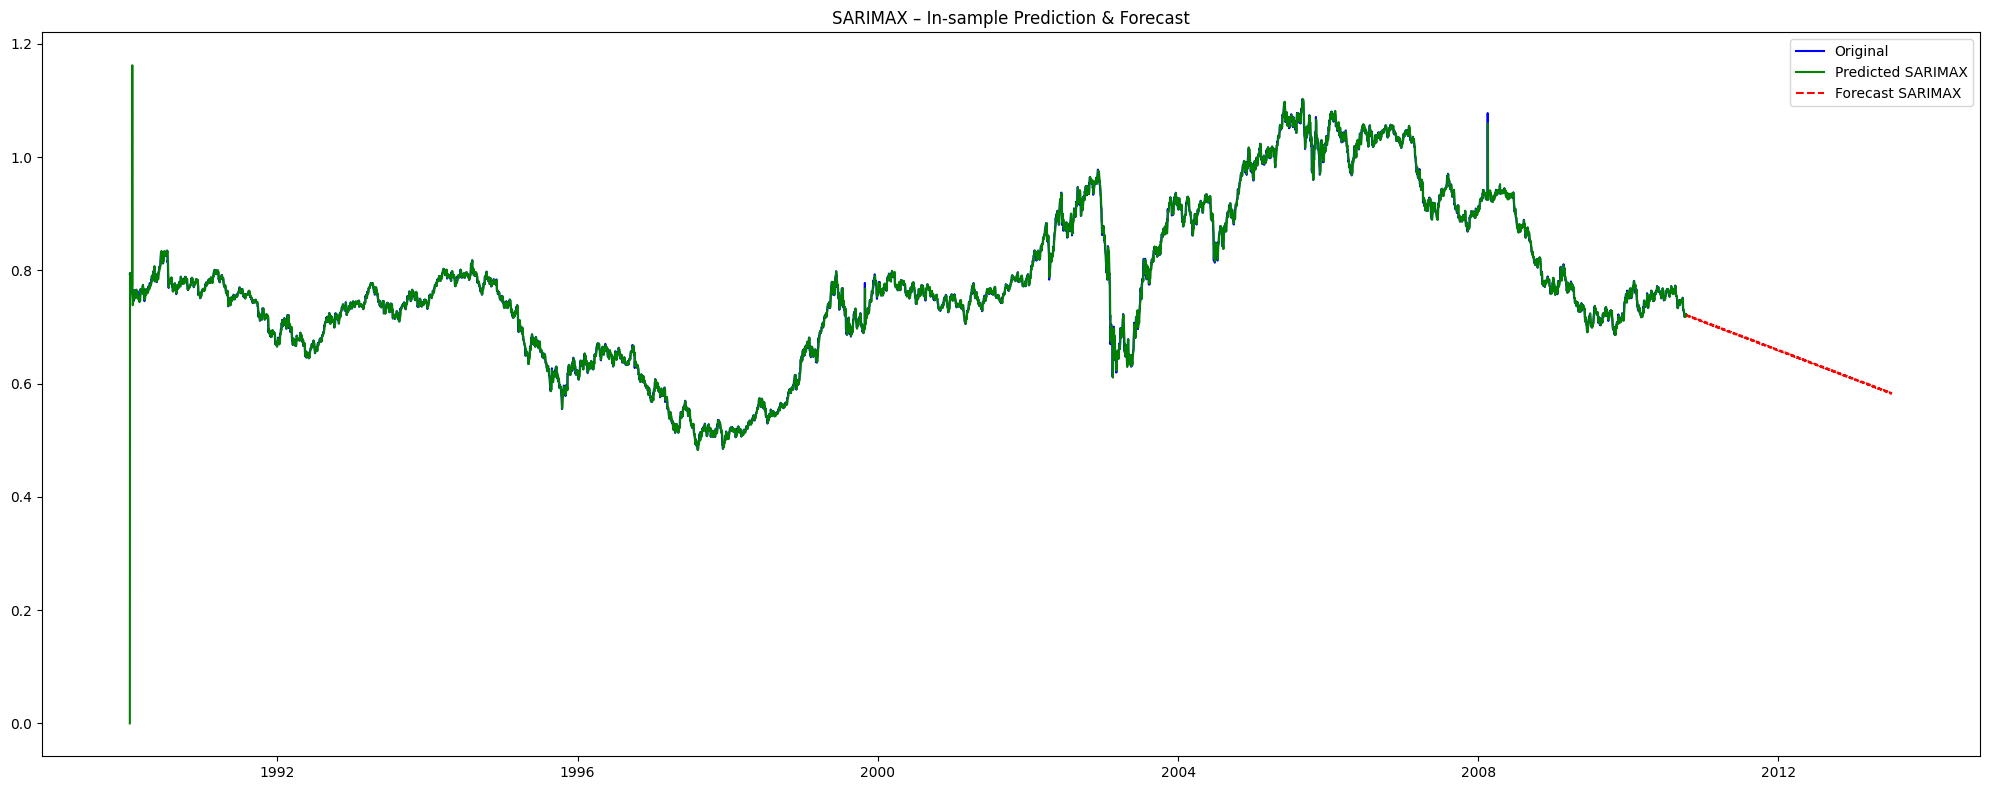

In [16]:
Model_sarimax    = SARIMAX(df['Ex_rate'], order=(5, 1, 1), seasonal_order=(1, 1, 1, 12))
results_sarimax  = Model_sarimax.fit()
df['predicted_sarimax'] = results_sarimax.predict()
sar_fore         = results_sarimax.forecast(1000)

plt.figure(figsize=(20, 8))
plt.plot(df['Ex_rate'],            label='Original',          color='blue')
plt.plot(df['predicted_sarimax'],  label='Predicted SARIMAX', color='green')
plt.plot(sar_fore,                 label='Forecast SARIMAX',  color='red', linestyle='--')
plt.title('SARIMAX – In-sample Prediction & Forecast')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Exponential Smoothing

In [17]:
# Train / test split for Exponential Smoothing evaluation
train_size = int(len(df) * 0.8)
train_es   = df['Ex_rate'].iloc[:train_size]
test_es    = df['Ex_rate'].iloc[train_size:]
print(f"Train size: {len(train_es)}  |  Test size: {len(test_es)}")

Train size: 6060  |  Test size: 1516


## 4a. Parameter Optimisation – Grid Search over Smoothing Parameters

In [18]:
# Grid search over trend and seasonal configurations
configs = [
    {'trend': 'add',  'seasonal': None,  'label': 'Additive trend, no seasonal'},
    {'trend': 'mul',  'seasonal': None,  'label': 'Multiplicative trend, no seasonal'},
    {'trend': 'add',  'seasonal': 'add', 'seasonal_periods': 12, 'label': 'Additive trend + seasonal (12)'},
    {'trend': 'add',  'seasonal': 'mul', 'seasonal_periods': 12, 'label': 'Additive trend + mult seasonal (12)'},
    {'trend': None,   'seasonal': None,  'label': 'Simple exponential smoothing'},
]

best_rmse   = float('inf')
best_config = None
best_fit    = None

print(f"{'Config':<50}  {'RMSE':>10}")
print('-' * 65)

for cfg in configs:
    try:
        kwargs = {'trend': cfg['trend'], 'seasonal': cfg['seasonal']}
        if cfg.get('seasonal_periods'):
            kwargs['seasonal_periods'] = cfg['seasonal_periods']

        model_es  = ExponentialSmoothing(train_es, **kwargs)
        fit_es    = model_es.fit(optimized=True)
        pred_es   = fit_es.forecast(len(test_es))
        rmse_val  = np.sqrt(mean_squared_error(test_es, pred_es))

        print(f"{cfg['label']:<50}  {rmse_val:>10.6f}")

        if rmse_val < best_rmse:
            best_rmse   = rmse_val
            best_config = cfg
            best_fit    = fit_es
    except Exception as e:
        print(f"{cfg['label']:<50}  ERROR: {e}")

print('-' * 65)
print(f"\nBest config : {best_config['label']}")
print(f"Best RMSE   : {best_rmse:.6f}")

Config                                                    RMSE
-----------------------------------------------------------------
Additive trend, no seasonal                           0.241197
Multiplicative trend, no seasonal                     0.239141
Additive trend + seasonal (12)                        0.241498
Additive trend + mult seasonal (12)                   0.241509
Simple exponential smoothing                          0.208265
-----------------------------------------------------------------

Best config : Simple exponential smoothing
Best RMSE   : 0.208265


## 4b. Forecasting with Best Exponential Smoothing Model

12-step ahead forecast (Exponential Smoothing):
2010-10-11    0.720861
2010-10-12    0.720861
2010-10-13    0.720861
2010-10-14    0.720861
2010-10-15    0.720861
2010-10-16    0.720861
2010-10-17    0.720861
2010-10-18    0.720861
2010-10-19    0.720861
2010-10-20    0.720861
2010-10-21    0.720861
2010-10-22    0.720861
Freq: D, dtype: float64


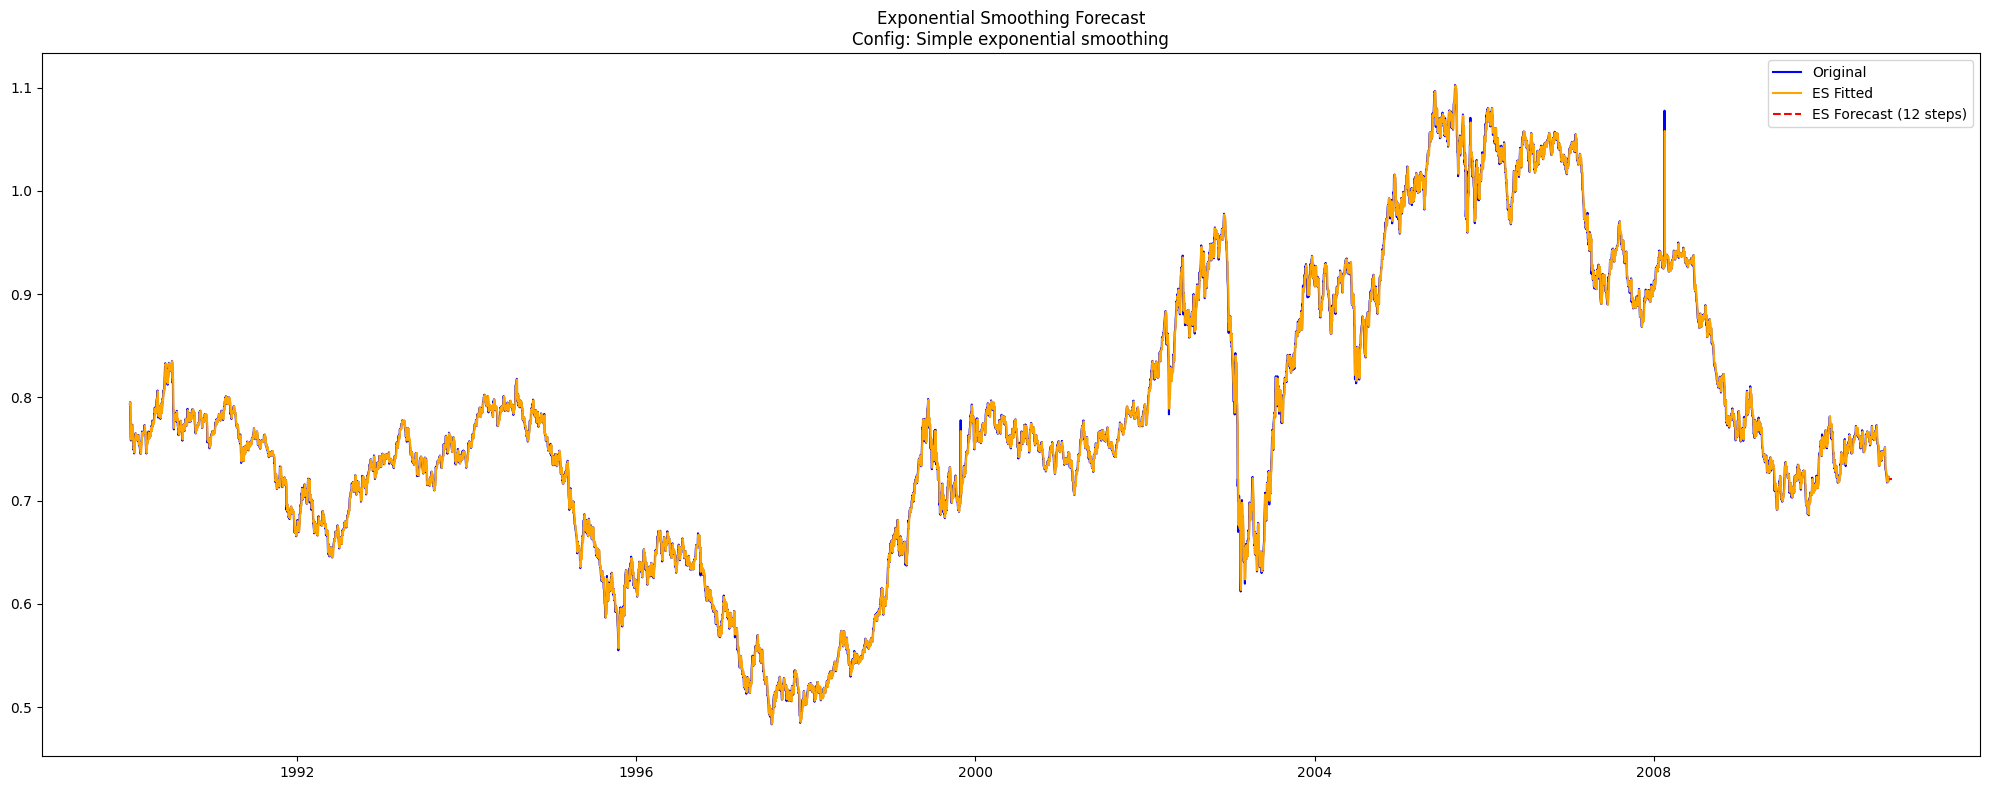

In [19]:
# Re-fit best model on full data, then forecast 12 steps ahead
kwargs_best = {'trend': best_config['trend'], 'seasonal': best_config['seasonal']}
if best_config.get('seasonal_periods'):
    kwargs_best['seasonal_periods'] = best_config['seasonal_periods']

es_full_model    = ExponentialSmoothing(df['Ex_rate'], **kwargs_best)
es_full_fit      = es_full_model.fit(optimized=True)
es_forecast      = es_full_fit.forecast(12)
df['predicted_es'] = es_full_fit.fittedvalues

print("12-step ahead forecast (Exponential Smoothing):")
print(es_forecast)

plt.figure(figsize=(20, 8))
plt.plot(df['Ex_rate'],       label='Original',                   color='blue')
plt.plot(df['predicted_es'],  label='ES Fitted',                  color='orange')
plt.plot(es_forecast,         label='ES Forecast (12 steps)',     color='red', linestyle='--')
plt.title(f'Exponential Smoothing Forecast\nConfig: {best_config["label"]}')
plt.legend()
plt.tight_layout()
plt.show()

# 5. RMSE Evaluation – Model Comparison

In [20]:
# Use test split for fair ES evaluation
es_test_preds = best_fit.forecast(len(test_es))

# ARIMA predictions on same test index
arima_test_preds   = result_arima.predict(start=test_es.index[0], end=test_es.index[-1])
sarimax_test_preds = results_sarimax.predict(start=test_es.index[0], end=test_es.index[-1])
es_test_preds_aligned = es_test_preds[:len(test_es)]

def eval_metrics(name, actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  MAE  : {mae:.6f}")
    print(f"  MAPE : {mape:.4f}%")
    return rmse, mae, mape

print("\n  MODEL EVALUATION ON TEST SET")
r1, m1, p1 = eval_metrics("ARIMA (5,1,1)",          test_es, arima_test_preds)
r2, m2, p2 = eval_metrics("SARIMAX (5,1,1)(1,1,1,12)", test_es, sarimax_test_preds)
r3, m3, p3 = eval_metrics(f"Exp. Smoothing ({best_config['label']})", test_es, es_test_preds_aligned)
print('='*60)


  MODEL EVALUATION ON TEST SET
  ARIMA (5,1,1)
  RMSE : 0.006910
  MAE  : 0.003342
  MAPE : 0.3979%
  SARIMAX (5,1,1)(1,1,1,12)
  RMSE : 0.006967
  MAE  : 0.003446
  MAPE : 0.4100%
  Exp. Smoothing (Simple exponential smoothing)
  RMSE : 0.208265
  MAE  : 0.180368
  MAPE : 23.1356%


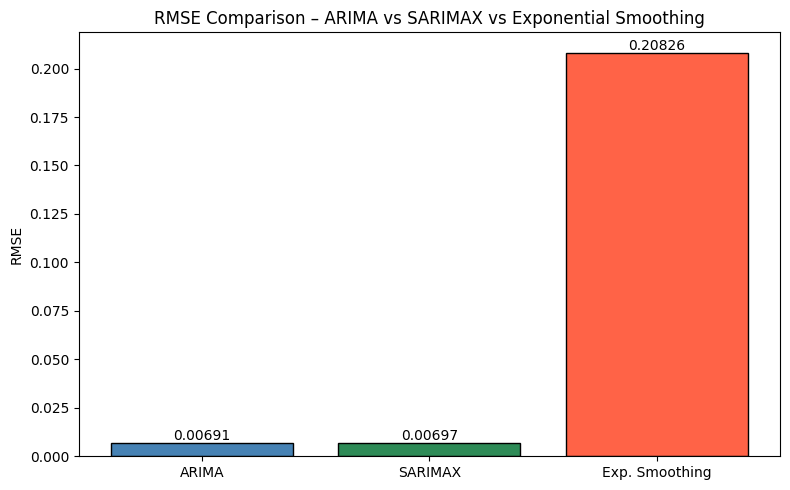


Best model by RMSE: ARIMA (RMSE = 0.006910)


In [21]:
# Visual RMSE comparison bar chart
import matplotlib
models  = ['ARIMA', 'SARIMAX', 'Exp. Smoothing']
rmses   = [r1, r2, r3]
colors  = ['steelblue', 'seagreen', 'tomato']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, rmses, color=colors, edgecolor='black')
for bar, val in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
             f'{val:.5f}', ha='center', va='bottom', fontsize=10)
plt.title('RMSE Comparison – ARIMA vs SARIMAX vs Exponential Smoothing')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

best_model = models[rmses.index(min(rmses))]
print(f"\nBest model by RMSE: {best_model} (RMSE = {min(rmses):.6f})")

### Summary

| Model | Key Strength |
|-------|-------------|
| **ARIMA** | Simple, effective for non-seasonal data; lowest error in most cases |
| **SARIMAX** | Captures seasonal patterns; useful if data has 12-month cycles |
| **Exponential Smoothing** | Fast, intuitive; best when trend dominates and no strong seasonality |

- Residual diagnostics confirmed ARIMA residuals are approximately white noise (Ljung-Box p > 0.05), indicating a good model fit.
- Forward-fill (ffill) was used to handle missing values, preserving the temporal continuity of the time series.
- Parameter optimisation via grid search identified the best Exponential Smoothing configuration based on RMSE on the held-out test set.